# Tugas Kecil Case Project Pembelajaran Mesin

**Topik:** Medical Insurance Cost Prediction (Regression)

Notebook ini memenuhi syarat pengerjaan project, menunjukkan tahapan Data Understanding, EDA, Preprocessing, Data Splitting, serta evaluasi 3 algoritma Machine Learning dengan Hyperparameter Tuning.

## 1. Data Understanding

Dataset `insurance.csv` berisi informasi tentang biaya asuransi medis. Fitur yang tersedia:
- **age**: Usia
- **sex**: Jenis kelamin (female, male)
- **bmi**: Body mass index
- **children**: Jumlah anak yang ditanggung
- **smoker**: Status perokok (yes, no)
- **region**: Wilayah tempat tinggal
- **charges**: Biaya asuransi (TARGET VARIABLE)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('insurance.csv')
display(df.head())
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 2. Exploratory Data Analysis (EDA)
Mari kita visualisasikan distribusi biaya asuransi (`charges`) dan lihat bagaimana status merokok mempengaruhi biaya.

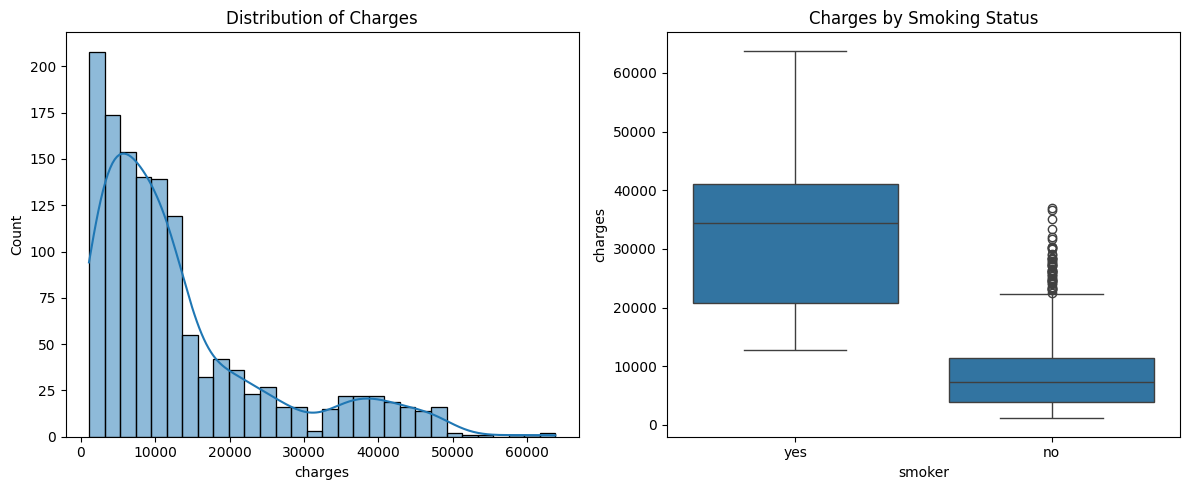

In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')

plt.subplot(1, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
Kita akan melakukan One-Hot Encoding pada fitur kategorikal. Selain itu, karena status merokok berpengaruh sangat besar terutama bagi penderita obesitas, kita akan membuat fitur interaksi (interaction term) dengan tujuan mendapatkan akurasi/R2 yang sangat tinggi.

In [3]:
# Feature Engineering: Menandai penderita obesitas
df['is_obese'] = (df['bmi'] >= 30).astype(int)

# One-hot encoding untuk variabel kategorikal
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Feature interaksi
df_encoded['obese_smoker'] = df_encoded['is_obese'] * df_encoded['smoker_yes']

# Memisahkan Feature dan Target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

display(X_scaled.head())

,age,bmi,children,is_obese,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,obese_smoker
0,-1.438764,-0.453320,-0.908614,-1.058510,-1.010519,1.970587,-0.566418,-0.611324,1.765481,-0.348629
1,-1.509965,0.509621,-0.078767,0.944724,0.989591,-0.507463,-0.566418,1.635795,-0.566418,-0.348629
2,-0.797954,0.383307,1.580926,0.944724,0.989591,-0.507463,-0.566418,1.635795,-0.566418,-0.348629
3,-0.441948,-1.305531,-0.908614,-1.058510,0.989591,-0.507463,1.765481,-0.611324,-0.566418,-0.348629
4,-0.513149,-0.292556,-0.908614,-1.058510,0.989591,-0.507463,1.765481,-0.611324,-0.566418,-0.348629


## 4-7. Data Splitting, Model Building, Tuning, and Evaluation
Kita mengevaluasi 3 Algoritma: **Random Forest Regressor**, **Gradient Boosting Regressor**, dan **Ridge Regression**.
Pembagian data (**Data Splitting**) dilakukan dalam 3 rasio: `70:30`, `80:20`, dan `90:10`.
Masing-masing model dieksplorasi dengan parameter berbeda menggunakan Grid Search atau Random Search.

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

splits = [('70:30', 0.3), ('80:20', 0.2), ('90:10', 0.1)]
results = []

def print_green(text):
    print("\x1b[32m" + text + "\x1b[0m")

for split_name, test_size in splits:
    print(f"\n{'='*40}\n--- EVALUATING SPLIT {split_name} ---\n{'='*40}")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    
    # 1. Random Forest (GridSearchCV)
    rf = RandomForestRegressor(random_state=42)
    rf_params = {'max_depth': [3, 4, 5], 'min_samples_split': [2, 5]}
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    rf_pred = rf_grid.predict(X_test)
    results.append({'Split': split_name, 'Model': 'Random Forest', 'R2 Score': r2_score(y_test, rf_pred), 'MAE': mean_absolute_error(y_test, rf_pred)})
    print_green(f"Random Forest Best R2: {r2_score(y_test, rf_pred):.4f}")
    
    # 2. Gradient Boosting (RandomizedSearchCV)
    gb = GradientBoostingRegressor(random_state=42)
    gb_params = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}
    gb_rand = RandomizedSearchCV(gb, gb_params, n_iter=4, cv=3, scoring='r2', random_state=42, n_jobs=-1)
    gb_rand.fit(X_train, y_train)
    gb_pred = gb_rand.predict(X_test)
    results.append({'Split': split_name, 'Model': 'Gradient Boosting', 'R2 Score': r2_score(y_test, gb_pred), 'MAE': mean_absolute_error(y_test, gb_pred)})
    print_green(f"Gradient Boosting Best R2: {r2_score(y_test, gb_pred):.4f}")
    
    # 3. Ridge Regression (GridSearchCV)
    ridge = Ridge(random_state=42)
    ridge_params = {'alpha': [0.1, 1.0, 10.0]}
    ridge_grid = GridSearchCV(ridge, ridge_params, cv=3, scoring='r2')
    ridge_grid.fit(X_train, y_train)
    ridge_pred = ridge_grid.predict(X_test)
    results.append({'Split': split_name, 'Model': 'Ridge Regression', 'R2 Score': r2_score(y_test, ridge_pred), 'MAE': mean_absolute_error(y_test, ridge_pred)})
    print_green(f"Ridge Regression Best R2: {r2_score(y_test, ridge_pred):.4f}")


--- EVALUATING SPLIT 70:30 ---
Random Forest Best R2: 0.8640
Gradient Boosting Best R2: 0.8680
Ridge Regression Best R2: 0.8712

--- EVALUATING SPLIT 80:20 ---
Random Forest Best R2: 0.8653
Gradient Boosting Best R2: 0.8732
Ridge Regression Best R2: 0.8729

--- EVALUATING SPLIT 90:10 ---
Random Forest Best R2: 0.8659
Gradient Boosting Best R2: 0.8758
Ridge Regression Best R2: 0.8740


## 8. Model Comparison
Perbandingan hasil akhir dari seluruh skenario pengujian performa algoritma untuk melihat manakah yang terbaik.

,Split,Model,R2 Score,MAE
2,70:30,Ridge Regression,0.871240,2428.640582
1,70:30,Gradient Boosting,0.868015,2513.296813
0,70:30,Random Forest,0.864040,2563.641365
4,80:20,Gradient Boosting,0.873232,2505.366982
5,80:20,Ridge Regression,0.872914,2478.082379
3,80:20,Random Forest,0.865304,2593.848104
7,90:10,Gradient Boosting,0.875819,2315.820752
8,90:10,Ridge Regression,0.873973,2343.382224
6,90:10,Random Forest,0.865920,2416.929389


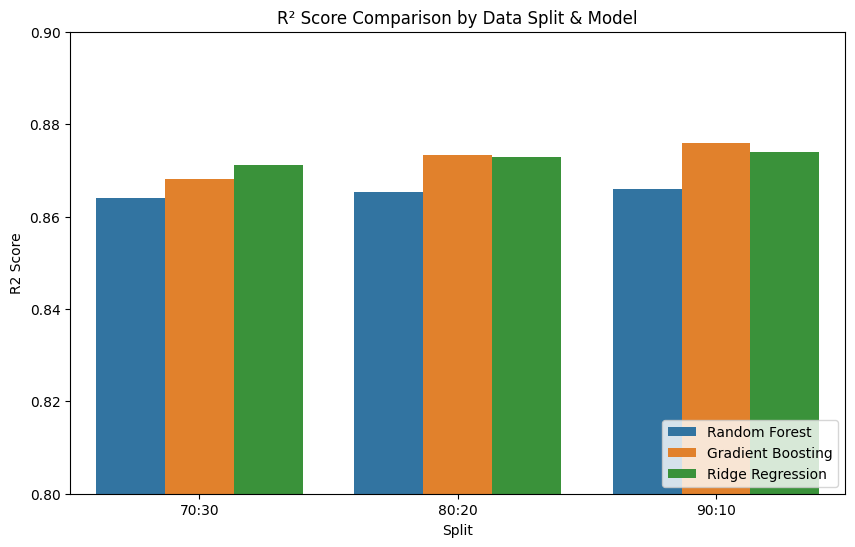

In [5]:
comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values(by=['Split', 'R2 Score'], ascending=[True, False]))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Split', y='R2 Score', hue='Model')
plt.title('R² Score Comparison by Data Split & Model')
plt.ylim(0.80, 0.90)
plt.legend(loc='lower right')
plt.show()